# Experimental
Notebook to generate Figure S.4

## Reqs

In order to run this notebook you have to download / get following file in addition to the files already present in the repository :
- `hg38/cytoBand-human-GRCh38-hg38.txt` # Follow instruction from `hg38/get_files.md` section `CYTOBAND FILE`
- `data/experimental/experimental.tsv` # Obtained from Zenodo

In [3]:
GENERATE_RESULTS = (
    True  # if set to true it will generate results in outputs/ directory.
)


from pathlib import Path
from random import randint

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import Rectangle, Polygon



# Matplotlib configuration
fontdict = {"size": 10, "family": "sans-serif"}
mpl.rc("font", **fontdict)
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
PROJECT_DIR = Path().absolute().parent

## Notebook's specific functions


In [4]:
def aggregate(data, agg_size, columns=None):
    """
    Aggregate genomic data by binning positions.

    Args:
        data: Input dataframe with 'chr', 'start', 'end' columns
        agg_size: Size of bins for aggregation
        columns: Columns to aggregate (default: all except chr, start, end)

    Returns:
        Aggregated dataframe
    """
    columns = columns or data.select(pl.exclude("start", "end", "chr")).columns

    return (
        data.group_by(["chr", pl.col("start") // agg_size])
        .agg(
            pl.col(columns).mean(),
            pl.col("start").min().alias("true_start"),
            pl.col("end").max(),
        )
        .drop("start")
        .rename({"true_start": "start"})
        .sort(pl.col("start"))
    )


def rank_normalize(s: pl.Series) -> pl.Series:
    """Normalize series by rank transformation."""
    return s.rank() / s.len()


### Plot

In [9]:
LABEL_COLORS = {"vipper": 4, "RADD": 9, "AP": 0, "7.4": 12}

# Plotting Configuration
CYTOBAND_DF = pl.read_csv(
    PROJECT_DIR / "hg38" / "cytoBand-human-GRCh38-hg38.txt", separator="\t"
)

GIE_COLORS = {
    "gneg": "white",
    "gpos25": "#C8C8C8",
    "gpos50": "#A0A0A0",
    "gpos75": "#707070",
    "gpos100": "black",
    "gvar": "#DCDCDC",
    "stalk": "#A0A0F0",
    "acen": "#B40000",
}

COLUMN_LABEL_MAP = {
    "7.4": r"$M_{\overline{\text{vIP}}}$",
    "vipper": r"$-\overline{\text{vIP}}$",
    "RADD": r"$\text{RADD}$",
    "AP": r"$\text{AP}$",
}


def _draw_cytoband(ax_band, chr_name, y_center=0, height=0.4, start=None, end=None):
    """Draw chromosome ideogram on axis."""
    chr_cytoband_df = CYTOBAND_DF.filter(pl.col("chrom") == chr_name)
    if start:
        chr_cytoband_df = chr_cytoband_df.filter(pl.col("chromEnd") > start)
    if end:
        chr_cytoband_df = chr_cytoband_df.filter(pl.col("chromStart") < end)

    # Draw bands
    for row in chr_cytoband_df.iter_rows(named=True):
        x0, x1 = row["chromStart"], row["chromEnd"]
        stain = row["gieStain"]
        color = GIE_COLORS.get(stain, "white")
        rect = Rectangle(
            (x0, y_center - height / 2),
            x1 - x0,
            height,
            facecolor=color,
            edgecolor="black",
            linewidth=0.5,
        )
        ax_band.add_patch(rect)

    # Draw centromere
    acen = chr_cytoband_df.filter(pl.col("gieStain") == "acen").to_dicts()
    if len(acen) == 2:
        left, right = acen

        # Left centromere polygon
        ax_band.add_patch(
            Polygon(
                [
                    (left["chromStart"], y_center - height / 2),
                    (left["chromEnd"], y_center),
                    (left["chromStart"], y_center + height / 2),
                ],
                closed=True,
                color=GIE_COLORS["acen"],
            )
        )

        # Right centromere polygon
        ax_band.add_patch(
            Polygon(
                [
                    (right["chromEnd"], y_center - height / 2),
                    (right["chromStart"], y_center),
                    (right["chromEnd"], y_center + height / 2),
                ],
                closed=True,
                color=GIE_COLORS["acen"],
            )
        )

    ax_band.set_ylim(-0.6, 0.6)
    ax_band.axis("off")


def _plot_chromosome_signal(
    ax_signal, chr_data, visible_columns, gap_threshold, plot_legend=True
):
    """Plot chromosome signal data with gap handling."""
    for col in visible_columns:
        x = chr_data["start"].to_numpy()
        y = chr_data[f"{col}_normed"].to_numpy()

        # Find gaps and split into segments
        gaps = np.where(np.diff(x) > gap_threshold)[0]
        segments = np.split(np.arange(len(x)), gaps + 1)

        color = mpl.cm.tab20c(LABEL_COLORS.get(col, randint(0, 20)))

        label_ploted = False
        for idx, seg in enumerate(segments):
            if (
                max(x[seg]) - min(x[seg]) < (max(x) - min(x)) * 0.1
            ):  # Si moins de 10% de la taille du chrom
                continue

            label = None if label_ploted else COLUMN_LABEL_MAP.get(col, col)
            ax_signal.plot(x[seg], y[seg], color=color, label=label)
            label_ploted = True


def _format_legend(ax_signal):
    """Format legend appearance."""
    legend = ax_signal.legend(
        frameon=True, framealpha=1, edgecolor="black", fontsize=10, loc="upper right"
    )
    legend.get_frame().set_linewidth(0.5)


In [5]:
def _format_axis_labels(ax_signal):
    """Format x-axis labels in Mb."""
    ax_signal.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}"))
    ax_signal.set_xlabel("Genomic Position (Mbp)")
    ax_signal.set_ylabel("Normalized Value")

def _format_axis_labels_from_range(ax_signal, x_max):
    """Format axis labels using the data range to determine appropriate unit (Kb or Mb)."""
    if x_max and x_max > 0:
        if x_max >= 1e6:
            scale, unit = 1e6, "Mbp"
        else:
            scale, unit = 1e3, "Kbp"
        ax_signal.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, pos: f"{x/scale:.0f}")
        )
        ax_signal.set_xlabel(f"Genomic Position ({unit})")
    else:
        ax_signal.set_xlabel("Genomic Position")
    ax_signal.set_ylabel("Normalized Value")


def plot_zoom_figure(
    data,
    zoom_levels,
    norm_function=rank_normalize,
    gap_threshold=500_000,
    figsize_width=8,
    signal_height=2.5,
    band_height=0.5,
    zoom_box_color="black",
    zoom_box_lw=1.5,
):
    """
    Create a multi-panel zoom figure with connecting lines between levels.

    zoom_levels: list of dicts with keys:
        - start (int|None): genomic start, None for full chromosome
        - end (int|None): genomic end, None for full chromosome
        - agg_size (int): bin size for aggregation
        - gaussian_filter (bool): apply gaussian smoothing (default False)
        - cytoband (bool): show cytoband (default True)
        - visible_columns (list): columns to plot
    """
    n = len(zoom_levels)
    chr_name = data["chr"].unique()[0]

    # Build row layout
    row_specs = []
    for lv in zoom_levels:
        if lv.get("cytoband", True):
            row_specs.append(band_height)
        row_specs.append(signal_height)

    fig, all_axes = plt.subplots(
        len(row_specs), 1,
        figsize=(figsize_width, sum(row_specs) + 0.4 * (n - 1)),
        gridspec_kw={"height_ratios": row_specs, "hspace": 0.55},
    )
    if len(row_specs) == 1:
        all_axes = [all_axes]

    # Assign axes to each zoom level
    ax_idx = 0
    ax_signals, ax_bands = [], []
    for lv in zoom_levels:
        if lv.get("cytoband", True):
            ax_bands.append(all_axes[ax_idx])
            ax_idx += 1
        else:
            ax_bands.append(None)
        ax_signals.append(all_axes[ax_idx])
        ax_idx += 1

    # Plot each level
    for i, lv in enumerate(zoom_levels):
        start = lv.get("start")
        end = lv.get("end")
        agg_size = lv["agg_size"]
        gf = lv.get("gaussian_filter", False)
        visible_columns = lv.get("visible_columns", ["RADD", "AP", "vipper"])

        chr_data = data
        if start is not None:
            chr_data = chr_data.filter(pl.col("start") >= start)
        if end is not None:
            chr_data = chr_data.filter(pl.col("end") <= end)
        chr_data = aggregate(chr_data, agg_size=agg_size)

        xmin = int(chr_data["start"].min())
        xmax = int(chr_data["end"].max())

        chr_data_norm = chr_data.with_columns(
            [norm_function(pl.col(col)).alias(f"{col}_normed") for col in visible_columns]
        )
        if gf:
            chr_data_norm = chr_data_norm.with_columns([
                pl.Series(f"{col}_normed", gaussian_filter1d(
                    chr_data_norm[f"{col}_normed"].to_numpy(), sigma=10))
                for col in visible_columns
            ])

        ax_sig = ax_signals[i]
        ax_band = ax_bands[i]

        ax_sig.grid(False)
        ax_sig.set_facecolor("white")
        _plot_chromosome_signal(ax_sig, chr_data_norm, visible_columns, gap_threshold, plot_legend=True)
        for spine in ["left", "bottom"]:
            ax_sig.spines[spine].set_visible(True)
        for spine in ["top", "right"]:
            ax_sig.spines[spine].set_visible(False)
        _format_legend(ax_sig)
        _format_axis_labels_from_range(ax_sig, xmax)

        if ax_band is not None:
            _draw_cytoband(ax_band, chr_name, start=start, end=end)
            ax_band.grid(False)
            ax_band.set_facecolor("white")
            # Must set xlim explicitly — band axis is not sharex with signal axis,
            # so patches drawn in genomic coords would map to billions of pixels otherwise.
            ax_band.set_xlim(xmin, xmax)
            ax_band.text(
                xmin - (xmax - xmin) * 0.03, 0, chr_name,
                va="center", ha="right", fontsize=10, fontweight="bold",
            )

    # Draw zoom rectangles on parent signal axes (before tight_layout)
    for i in range(n - 1):
        next_lv = zoom_levels[i + 1]
        x0 = next_lv.get("start", 0)
        x1 = next_lv.get("end", int(data["end"].max()))
        if any([x0, x1]):
            ax_parent = ax_signals[i]
            y0, y1 = ax_parent.get_ylim()
            rect = Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                linewidth=zoom_box_lw, edgecolor=zoom_box_color,
                facecolor="none", zorder=4, clip_on=False,
            )
            ax_parent.add_patch(rect)

    plt.tight_layout(h_pad=0.1)

    # Convert data/axes coordinates to figure-fraction coordinates AFTER layout,
    # then draw simple Line2D objects. This avoids ConnectionPatch whose unbounded
    # data-coordinate extent can inflate the figure when bbox_inches='tight' is used.
    fig.canvas.draw()
    for i in range(n - 1):
        next_lv = zoom_levels[i + 1]
        x0 = next_lv.get("start", 0)
        x1 = next_lv.get("end", int(data["end"].max()))
        if any([x0, x1]):
            ax_parent = ax_signals[i]
            ax_child_top = ax_bands[i + 1] if ax_bands[i + 1] is not None else ax_signals[i + 1]
            y_bottom = ax_parent.get_ylim()[0]
            for x_par, x_child in [(x0, 0.0), (x1, 1.0)]:
                p_frac = fig.transFigure.inverted().transform(
                    ax_parent.transData.transform((x_par, y_bottom))
                )
                c_frac = fig.transFigure.inverted().transform(
                    ax_child_top.transAxes.transform((x_child, 1.0))
                )
                line = mpl.lines.Line2D(
                    [p_frac[0], c_frac[0]], [p_frac[1], c_frac[1]],
                    transform=fig.transFigure,
                    color=zoom_box_color, lw=zoom_box_lw * 0.6, zorder=5, clip_on=False,
                )
                line.set_in_layout(False)
                fig.add_artist(line)

    return fig


## Generate_plot

In [7]:
datas = pl.read_csv(
    PROJECT_DIR / "data" / "experimental" / "experimental.tsv", separator="\t"
).with_columns(
    (
        (pl.col("C") + pl.col("G"))
        / (pl.col("C") + pl.col("G") + pl.col("A") + pl.col("T"))
    ).alias("GC"),
    -pl.col("vipper").alias("vipper"),
)

chr,start,end,RADD,AP,vipper,7.2,7.3,7.4,7.5,7.6,7.7,7.8,A,T,C,G,GC
str,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
"""chr1""",792600,792800,208.89,0.119255,-6.351157,1,4,11,17,38,66,108,47,84,38,31,0.345
"""chr1""",792800,793000,8.4125,0.11168,-6.552395,1,5,20,31,60,81,129,44,59,73,24,0.485
"""chr1""",793000,793200,118.635,0.064813,-6.29344,1,4,10,20,48,75,116,57,61,39,43,0.41
"""chr1""",793200,793400,36.6425,0.075229,-6.480196,1,8,18,26,52,79,111,49,68,53,30,0.415
"""chr1""",793400,793600,1.995,0.164578,-6.340972,1,4,13,20,43,62,94,38,98,42,22,0.32
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chrY""",26636400,26636600,0.5,0.02311,-6.222073,0,4,15,20,39,69,106,66,59,40,35,0.375
"""chrY""",26636600,26636800,0.5,0.005267,-6.231944,1,2,10,19,52,78,106,65,56,33,46,0.395
"""chrY""",26636800,26637000,0.5,0.00685,-6.090612,2,13,25,34,66,97,136,47,52,48,53,0.505


/tmp/ipykernel_590321/60919517.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=0.1)


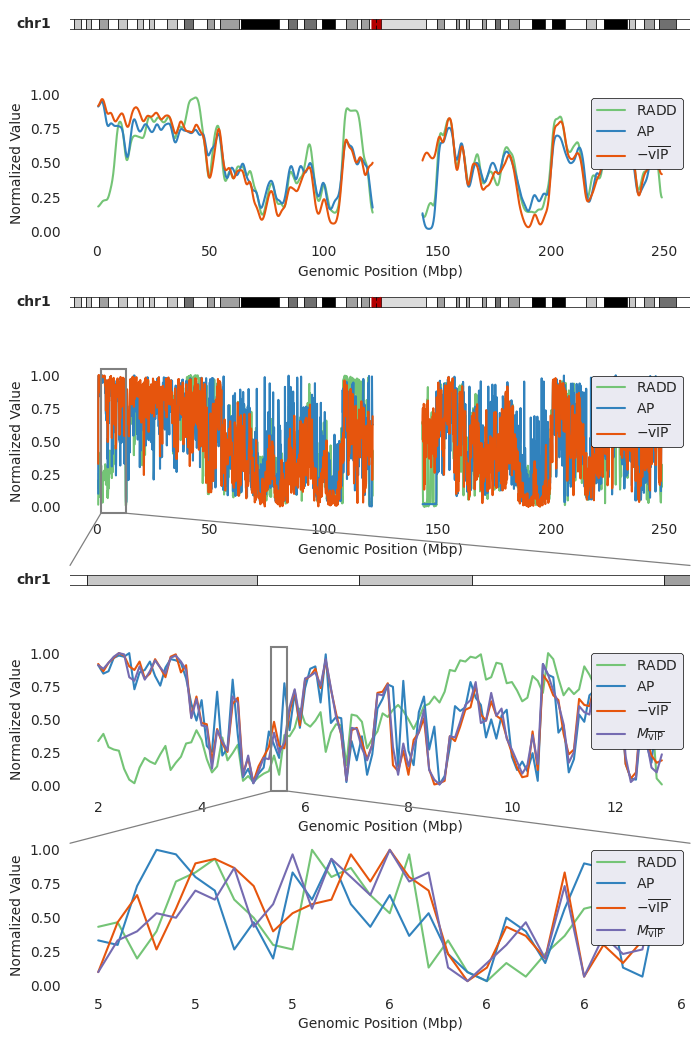

In [10]:
zoom_levels = [
    dict(
        start=None, end=None,
        agg_size=100_000, gaussian_filter=True, cytoband=True,
        visible_columns=["RADD", "AP", "vipper"],
    ),
    dict(
        start=None, end=None,
        agg_size=100_000, gaussian_filter=False, cytoband=True,
        visible_columns=["RADD", "AP", "vipper"],
    ),
    dict(
        start=2_000_000, end=13_000_000,
        agg_size=100_000, gaussian_filter=False, cytoband=True,
        visible_columns=["RADD", "AP", "vipper", "7.4"],
    ),
    dict(
        start=5_350_000, end=5_650_000,
        agg_size=10_000, gaussian_filter=False, cytoband=False,
        visible_columns=["RADD", "AP", "vipper", "7.4"],
    ),
    dict(
        start=5_485_000, end=5_515_000,
        agg_size=1_000, gaussian_filter=False, cytoband=False,
        visible_columns=["RADD", "AP", "vipper", "7.4"],
    ),
    dict(
        start=5_495_000, end=5_505_000,
        agg_size=200, gaussian_filter=False, cytoband=False,
        visible_columns=["RADD", "AP", "vipper", "7.4"],
    ),
]

fig = plot_zoom_figure(
    datas.filter(pl.col("chr") == "chr1").drop_nulls(),
    zoom_levels=zoom_levels[:4],
    norm_function=rank_normalize,
    zoom_box_color="grey"
)
if GENERATE_RESULTS:
    output_path = PROJECT_DIR / "outputs" / "experimental" / "fig1_zoom.svg"
    output_path.parent.mkdir(parents=True, exist_ok=True),
    fig.savefig(output_path, bbox_inches="tight")
plt.show()
